# Krachtactuator Ontwerpopdracht

In de eerste 4 weken van het vak DEF-D hebben jullie simulaties gedaan van verschillende opstellingen in de electrostatica. Jullie zijn in week 3.6 bij het vak electromagnetisme doorgegaan met de magnetostatica. Deze opdracht gaat in op het simuleren van deze magnetostatica.

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

De opdracht bestaat uit de volgende sub-onderdelen:
1) Afleiden van een analytische vergelijking
2) Criteria opstellen
3) Simuleren om de grenzen van jullie ontwerpparameters te bepalen
4) Numeriek berekenen van het magneetveld
5) Numeriek berekenen van het magneetveld van een solenoide
6) Bereken krachtrespons van een kracht actuator
7) Beoordeling van de criteria

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.9 beoordeeld en herkansingen zijn in week 3.10, zie de studiehandleiding voor details.

Technische Instructies:
- Download de zip map die op brightspace staat en unzip deze.
- Creëer een nieuwe branch in je Github repo voor deze opdracht.
- Plaats de geunzipte map op de juiste plek in jouw branch, zoals in de handleiding op brightspace staat.
- Nodig je teamgenoot uit als collaborateur op jouw repo.

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Probeer de voorbeeld code te begrijpen.
- Op een aantal plekken zijn voorbeelden gegeven of bepaalde numerieke methodes sterk versimpeld. Deze code kunnen reprocuderen is niet een leerdoel van dit vak en zal later in de opleiding voorkomen. Denk hierbij aan het integreren en differentieeren, probeer deze dingen wel te begrijpen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# DEF-D opdracht 2: Ontwerp een solenoïdale krachtactuator


<img align="right" style="margin-left:15px" src="figures\solenoidactuator.png" width="600">


In deze ontwerpopdracht ga je een krachtactuator ontwerpen gebaseerd op een solenoïde en een permanente magneet. Deze lineaire krachtactuatoren worden gebruikt om bijvoorbeeld kleppen en afsluiters elektronisch te bedienen. Ook komen ze in vele huidshoudelijk apparaten voor. Hiernaast zie je een plaatje van een krachtactuator van de buitenkant en van de doorsnede. De krachtactuator bestaat uit een solenoïde (spoel), dat is een spiraalvormige stroomkring waar een stroom doorheen loopt. Zoals je weet kan je met een solenoide een redelijk homogeen veld maken als de solenoide lang en smal is. In de solenoïde  zit een cilinder,een zogeheten plunjer, die kan schuiven in de solenoïde. De plunjer is verbonden met het object dat je wilt bewegen. De plunjer kan gemaakt zijn van een magnetisch materiaal met een hoge magnetische permeabiliteit of van een permanente magneet. In dit voorbeeld kiezen we voor een plunjer van magnetiseerbaar materiaal.

Voor het ontwerpen van de actuator gaan we eerst de kracht van de actuator uitrekenen met behulp van analytische theorie. We nemen eerst aan dat de solenoïde ideaal is en leiden daarvoor een analytische vergelijking af. Nadat we een eerste ontwerp hebben gemaakt gebaseerd op de analytische oplossing gaan we simuleren hoe goed onze krachtactuator echt werkt en of we het ontwerp nog kunnen verbeteren. Daar gaan we!

## Deel 1: afleiden van een analytische vergelijking

Hier onder ze je een detaildoorsnede van de solenoïde. De solenoïde heeft een lengte $L_s$, $N$ wikkelingen, een straal $r_s$ en er loopt een constante stroom $I$ door de draad. De plunjer is een afstand $z_p$ in de solenoide geschoven en moet over een zo groot mogelijke afstand een kracht uitoefenen. Een ideale solenoïde heeft binnenin een constant veld dat overal langs de as is gericht, buiten de solenoïde is het veld nul. Daarnaast nemen we aan dat het magnetisch materiaal homogeen en lineair is en een relatieve permeabiliteit $\mu_r$ heeft.

<center>
<img src="figures\solenoidactuatorgraph.png" width="1000">
</center>

**Opdracht 1**

a. Pas de wet van Ampère toe voor het $\mathbf{H}$-veld met gebruik van contour $\cal C$.\
b. Leidt een vergelijking af voor het $\mathbf{B}$-veld als functie van $z_p$.\
c. Voldoet jouw afleiding aan de randvoorwaarden voor het H en B veld?

Voeg jullie afleiding hier als png toe.
![alt text](digiopdracht2fotos/image0.jpeg)
![alt text](digiopdracht2fotos/image8.jpeg)
![alt text](digiopdracht2fotos/image9.jpeg)

Het randveld van de solenoïde zal de plunjer de solenoïde intrekken. Echter, het berekenen van de randvelden is een hele klus, we zullen dit later doen. We gebruiken hier een aanpak soortgelijk aan die voor een dielektricum in een condensator. Allereerst berekenen we de totale energie van het systeem met behulp van $W = \frac{1}{2} \int_{\cal V} \mathbf{H} \cdot \mathbf{B} \, d\tau $. Daarna bepalen we de kracht op de plunjer door de afgeleide van de energie naar de positie te nemen. We nemen aan dat de plunjer dezelfde straal heeft als de solenoide, $r_s$. 

**Opdracht 2**

Bereken de totale hoeveelheid energie in de solenoïde als functie van $z_d$ door de veldenergie over het volume van de solenoïde te integreren met behulp van bovenstaande vergelijking.

Voeg jullie afleiding hier als png toe.
![alt text](digiopdracht2fotos/image7.jpeg)

Zoals je wellicht ziet uit je afleiding is de energie van de plunjer groter als de plunjer er geheel uit is en kleiner als de plunjer er geheel in is. De afgeleide van de energie naar de positie $z_p$ geeft dan ook een kracht die de plunjer naar buiten beweegt. Dit is fysisch niet wat er gebeurd. Wat we in de afleiding niet hebben meegenomen is de energie die het kost om de stroom te laten stromen. Het veranderende magneetveld veroorzaakt door het naar binnen bewegen van de magneet (wet van Faraday) geeft een stroom tegengesteld aan de aangelegde stroom, de stroombron moet dan dus meer vermogen gaan leveren om de stroom op gang te houden. Als we dit effect wel meenemen blijkt dat de grootte van de kracht gelijk is, maar dat deze dan de plunjer de solenoide intrekt. We gaan hier niet verder op in.


**Opdracht 3**

Bereken de kracht van de spoel op de plunjer.

Voeg hier een png toe van jullie afleiding.
![alt text](digiopdracht2fotos/image6.jpeg)

## Deel 2: Criteria opstellen

Jullie gaan nu een magnetische kracht actuator ontwerpen hiervoor gaan jullie nu een ontwerpcyclus doorlopen.

**Opdracht 4**

a. Bedenk en schets vijf toepassingen van een kracht actuator.\
b. Kies uit deze toepassingen minimaal 2 toepassingen voor een kracht actuator om verder mee door te rekenen.

Plaats hier een foto van jullie vijf schetsen met uitleg over wat er te zien is.
![alt text](digiopdracht2fotos/image5.jpeg)
![alt text](digiopdracht2fotos/image1.jpeg)

**Opdracht 5**

We gaan nu verder kijken naar de criteria van jullie kracht actuatoren. Wij hebben alvast twee essentiele criteria vastgesteld zodat we hier later in de opdracht mee verder kunnen rekenen. Hieronder zijn 4 veelgebruikte stroombronnen benoemd die jullie gaan gebruiken voor een van de criteria.

| Spanningsbron             | Stroomsterkte | Voltage | draad dikte van de spoel |
|:--------------------------|:--------------|:--------|:-------------------------|
| Arduino uno digital pin   | 40 mA         | 5 V     | 0.05 mm                  |
| 9 Volt batterij           | 500 mA        | 9 V     | 0.1  mm                  |
| 40 Watt telefoon oplader | 2 A           | 20 V    | 0.2 mm                   |
| Een auto batterij         | 180 A         | 12 V    | 1.5 mm                   |


a. Kies een van de hierboven benoemde stroombronnen om te gebruiken in jullie ontwerp. \
b. Gebruik de methode uit het college 'schattend rekenen' om voor elke toepassing de minimale kracht die de actuator moet kunnen leveren voor jullie toepassing te bepalen.\
c. Denk na over wat de straal van jullie actuator mag zijn. \
d. Bedenk nog 1 ander criterium per toepassing.

Plaats hier een foto van jullie uitwerkingen op vraag 5.
![alt text](digiopdracht2fotos/digiopdracht2verbeterdeopdracht5/image1.jpeg)
![alt text](digiopdracht2fotos/digiopdracht2verbeterdeopdracht5/image0.jpeg)

## Deel 3: Simuleren om de grenzen van jullie ontwerpparameters te bepalen

Jullie zullen nu simulaties gaan uitvoeren om de grenzen van jullie ontwerpparameters op te zoeken. Dit doen jullie voor jullie twee gekozen toepassingen en een deuractuator. Deze deuractuator moet een deur van het slot afhaalen door een kracht van 40 N uit te oefenen, gebruikt een 9 volt batterij als stroombron, de plunjer is gemaakt van ijzer en de straal van de actuator is 0.01 m.

**Opdracht 6**

Zet de relevante parameters in een Python script en maak een Python functie die met behulp van de wet van Ohm de maximale draadlengte uitrekent. Print de maximale draadlengte bij het uitvoeren van het script.

Plaats in deze cel een png met jullie eventuele analytische uitwerkingen.

In [2]:
###
###Hier jouw code###
###
## Deel 3: Simuleren om de grenzen van jullie ontwerpparameters te bepalen

def maximale_draadlengte(U, I, r_d, rho=1.68e-8):
    R_max = U / I
    A = np.pi * r_d**2
    L_max = (R_max * A) / rho
    return L_max

L_draad_40W = maximale_draadlengte(20, 2, 0.0002)
L_draad_9V  = maximale_draadlengte(9, 0.5, 0.0001)

print(f"Maximale draadlengte 40 W oplader: {L_draad_40W:.2f} m")
print(f"Maximale draadlengte 9 V batterij: {L_draad_9V:.2f} m")

Maximale draadlengte 40 W oplader: 74.80 m
Maximale draadlengte 9 V batterij: 33.66 m


**Opdracht 7**

Leidt een vergelijking af voor het minimale aantal wikkelingen $N$ die je nodig hebt om het gewicht op te kunnen tillen. Voeg je afleiding als png toe aan je notebook.

Plaats hier een png met jullie afleiding.
![alt text](digiopdracht2fotos/image2.jpeg)

We gaan nu de ontwerpvrijheid verkennen. Gegeven de materiaalparameters en de eigenschappen van de stroombron kunnen we de verhouding tussen de lengte en de straal van de solenoide kiezen.

**Opdracht 8**

Schrijf een enkele Python functie die het minimum en maximum aantal wikkelingen uitrekent als functie van $L_s$, $r_s$, $r_d$ en $I$. De functie moet de volgende voorwaarden controleren
1) Het minimum aantal wikkelingen wordt gegeven door de hiervoor afgeleide relatie van het aantal wikkelingen om de benodigde kracht te genereren. 
2) Het maximum aantal wikkelingen wordt gegeven door de draaddikte $r_d$ en de lengte $L_s$
3) Het maximum aantal wikkelingen wordt gegeven door de draadlengte en de straal van de solenoide
4) Het maximum aantal wikkelingen moet groter zijn dan het minimum aantal wikkelingen

Het maximum aantal wikkelingen is de kleinste van voorwaarde 2) en 3). Geef een foutmelding als het minimum aantal windingen groter is dan het maximum aantal windingen.

Plaats hier een png met jullie eventuele analytische afleiding.

In [3]:
### BEGIN SOLUTION
def aantal_wikkelingen(params):
    L_s = params["L_s"]
    r_s = params["r_s"]
    r_draad = params["r_draad"]
    I = params["I"]
    F_min = params["F_min"]
    z_p = params["z_p"]
    mu_r = params["mu_r"]
    L_draad_max = params["L_draad_max"]

    mu_0 = 4 * np.pi * 1e-7

    D = z_p + mu_r * (L_s - z_p)

    # minimaal aantal windingen
    N_min = (D / I) * np.sqrt(
        (2 * F_min) / (np.pi * r_s**2 * mu_0 * mu_r * (mu_r - 1))
    )

    # maximaal aantal windingen op basis van spoellengte
    N_max_1 = L_s / r_draad

    # maximaal aantal windingen op basis van draadlengte
    N_max_2 = L_draad_max / (2 * np.pi * r_s)

    N_max = min(N_max_1, N_max_2)

    if N_min > N_max:
        return np.nan, np.nan

    return N_min, N_max
    


Een parameter plot geeft ons inzicht in de haalbaarheid van het idee. In dit geval willen we kijken naar het mogelijke aantal wikkelingen en de lengte van onze solenoide. Hieronder staat een voorbeeld van code die een voorbeeld plot creëert met minimale eis $y=x$ en de maximale eis $y=2x$.

Text(0, 0.5, 'y')

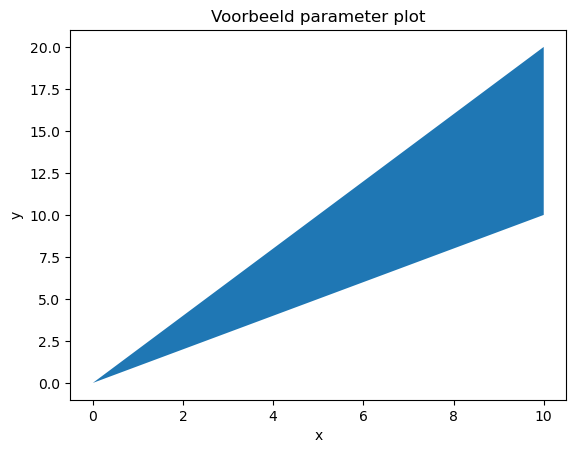

In [4]:
x = np.linspace(0,10,100)
y_min = x # Minimale eis
y_max = 2*x # Maximale eis

plt.fill_between(x,y_min,y_max) # De ruimte tussen de eisen vullen
plt.title("Voorbeeld parameter plot")
plt.xlabel("x")
plt.ylabel("y")


**Opdracht 9**

Maak een parameterplot met behulp van bovenstaand gedefinieerde functie voor de drie solenoideactuatoren voor $L_s$ tussen 0 en 1 m in 50 stappen. Een parameter plot ziet er hier uit als een plot tussen het minimale aantal wikkelingen en het maximaal aantal wikkelingen.



Waterklep: 49 van de 50 punten haalbaar
Deurslot: 49 van de 50 punten haalbaar
Deuractuator (40 N): 0 van de 50 punten haalbaar


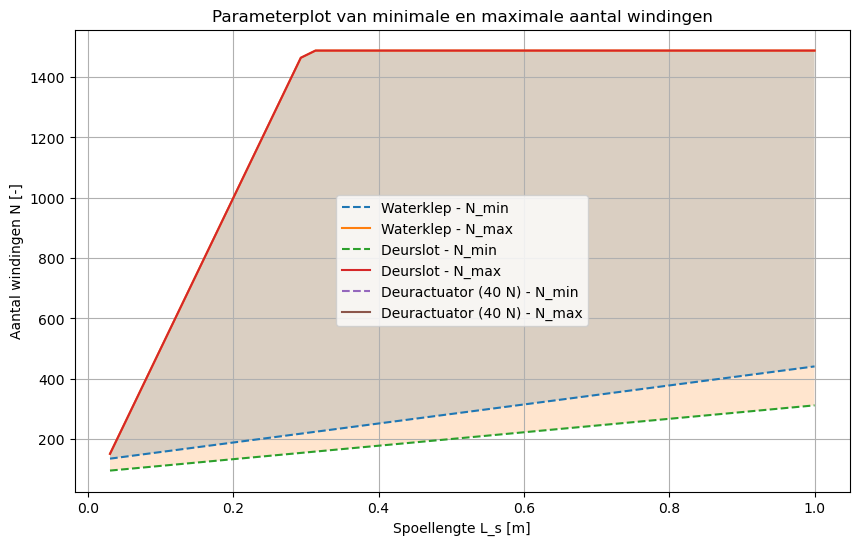

In [5]:
###
###Jouw code hier###
###
L_s_array = np.linspace(0.01, 1.0, 50)

L_draad_40W = maximale_draadlengte(20, 2, 0.0002)
L_draad_9V  = maximale_draadlengte(9, 0.5, 0.0001)

actuatoren = {
    "Waterklep": {
        "r_s": 0.008,
        "r_draad": 0.0002,
        "I": 2.0,
        "F_min": 2.0,
        "mu_r": 200,
        "L_draad_max": L_draad_40W,
        "slag": 0.002
    },
    "Deurslot": {
        "r_s": 0.008,
        "r_draad": 0.0002,
        "I": 2.0,
        "F_min": 1.0,
        "mu_r": 200,
        "L_draad_max": L_draad_40W,
        "slag": 0.002
    },
    "Deuractuator (40 N)": {
        "r_s": 0.010,
        "r_draad": 0.0001,
        "I": 0.5,
        "F_min": 40.0,
        "mu_r": 200,
        "L_draad_max": L_draad_9V,
        "z_p_vast": 0.020
    }
}

plt.figure(figsize=(10, 6))

for naam, params in actuatoren.items():
    N_min_list = []
    N_max_list = []

    for L_s in L_s_array:
        p = params.copy()
        p["L_s"] = L_s

        if "slag" in p:
            p["z_p"] = max(0, L_s - p["slag"])
        else:
            p["z_p"] = p["z_p_vast"]

            # fysisch ongeldige situatie vermijden
            if L_s <= p["z_p"]:
                N_min_list.append(np.nan)
                N_max_list.append(np.nan)
                continue

        # let op: hier geen debug=False gebruiken als jouw functie dat niet kent
        N_min, N_max = aantal_wikkelingen(p)

        N_min_list.append(N_min)
        N_max_list.append(N_max)

    N_min_list = np.array(N_min_list)
    N_max_list = np.array(N_max_list)

    haalbaar = np.sum(N_max_list >= N_min_list)
    print(f"{naam}: {haalbaar} van de {len(L_s_array)} punten haalbaar")

    plt.plot(L_s_array, N_min_list, linestyle="--", label=f"{naam} - N_min")
    plt.plot(L_s_array, N_max_list, label=f"{naam} - N_max")

    plt.fill_between(
        L_s_array,
        N_min_list,
        N_max_list,
        where=(N_max_list >= N_min_list),
        alpha=0.2
    )

plt.xlabel("Spoellengte L_s [m]")
plt.ylabel("Aantal windingen N [-]")
plt.title("Parameterplot van minimale en maximale aantal windingen")
plt.grid(True)
plt.legend()
plt.show()


Voor de deuractuator blijkt uit de parameterplot dat voor alle onderzochte waarden van $L_s$ het minimaal benodigde aantal windingen groter is dan het maximaal realiseerbare aantal windingen.
Dit betekent dat er binnen de gekozen randvoorwaarden (40 N, 9 V, 0,5 A) geen haalbaar ontwerp bestaat.
Om wel tot een werkend ontwerp te komen,kunnen de parameters zo worden aangepast:

hogere stroombron gebruiken
grotere spoelstraal
kleinere krachteis
materiaal met hogere permeabiliteit


**Opdracht 10**

Maak voor elke actuator een keuze voor de lengte van de spoel, de straal van de spoel en de lengte van de draad.

Op basis van de parameterplot uit opdracht 9 is voor de waterklep gekozen voor een spoellengte van 0,04 m en een spoelstraal van 0,008 m.
Bij deze waarden ligt het minimaal benodigde aantal windingen onder het maximaal haalbare aantal windingen, waardoor een werkbaar ontwerp mogelijk is.
Er is gekozen voor ongeveer 150 windingen, wat overeenkomt met een draadlengte van ongeveer 7,5 m.

Voor het elektromagnetisch deurslot is gekozen voor een spoellengte van 0,03 m en een spoelstraal van 0,008 m.
Ook hier ligt het minimaal benodigde aantal windingen onder het maximaal haalbare aantal windingen.
Er is gekozen voor ongeveer 110 windingen, wat overeenkomt met een draadlengte van ongeveer 5,5 m.

Voor de deuractuator met een vereiste kracht van 40 N is geen haalbaar ontwerp gevonden.
Binnen de gegeven elektrische en geometrische randvoorwaarden is het niet mogelijk om voldoende windingen te realiseren om de vereiste kracht op te wekken.
Daarom kan voor deze actuator geen definitieve keuze worden gemaakt voor spoellengte, spoelstraal en draadlengte.

Bovenstaande analytische berekening is een goede start voor het ontwerp en geeft aan welke parameters je kan optimaliseren. Echter in een echte solenoide zullen er allerlei niet ideale effecten een rol spelen. Zo zal het veld in de solenoide niet constant zijn (het is geen oneindig lange solenoide) en zijn er randvelden aan de uiteinden van de solenoide. We zullen nu de kracht-afstand relatie van de solenoide krachtactuator uitrekenen. Deze kan dan verder geoptimaliseerd worden om de kracht-uitwijking relatie zo lineair mogelijk te maken.

## Deel 4: Numeriek berekenen van het magneetveld van een rechte stroomdraad

<img align="right" style="margin-left:15px" src="wiregeometry.jpg" width="300">

Omdat we in ons ontwerp een stroombron gebruiken met een aangelegde stroom voeren we de berekeningen uit met het $\mathbf{H}$-veld. De analytische oplossing voor het $\mathbf{H}$-veld om een oneindig lange stroomdraad is het met meest eenvoudige voorbeeld voor het berekenen van het magnetisch veld en het toepassen van de wet van Ampere. In cilindrische coordinaten wordt het magneetveld op afstand $s$ veroorzaakt door stroom $I$ gegeven door (zie Griffiths blz. 282, voorbeeld 6.2)
$$
    \mathbf{B} =\frac{I}{2 \pi s} \hat{\boldsymbol{\phi}} \, .
$$


Alleen in de meest eenvoudige stroomgeometrieën kunnen we het magneetveld analytisch berekenen. In meer complexe stroomgeometrieën moeten we numerieke methoden gebruiken om het magneetveld te berekenen. In deze opdracht willen we een numerieke methode ontwikkelen voor een complexe stroomgeometrie, maar gebruiken we het voorbeeld van de oneindig lange stroomdraad om onze numerieke methode te testen. We gaan het magneetveld berekenen met de wet van Biot-Savart (zie Griffiths blz. 222, Vgl. 5.34) maar dan voor het $\mathbf{H}$-veld

$$
    \mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I \int \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

De wet van Biot-Savart laat zien dat het magneetveld wordt gegeven door een som over lijnelementen $d\mathbf{l}$ met bijdrage

$$
    d\mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I  \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

**Opdracht 11**

Schrijf een Python funktie met als invoer de variabelen:
* een array die de veldpositie $\mathbf{r}$ aangeeft
* een array die de de bronpositie $\mathbf{r}'$ aangeeft
* een array die de lengte $d\mathbf{l}$ aangeeft

De functie moet het magneetveld van een lijnelement $d\mathbf{l}$ berekenen. Gebruik voor het uitrekenen van het uitproduct de numpy $\verb|cross|$ functie en de hierboven gegeven formule voor $d\mathbf{H}$.

Bereken met deze functie alle componenten van het magneetveld voor een veldpositie op $x=0.1$ m voor een stroombronelement in de oorsprong met een stroom van 6 A een lengte van $d\mathbf{l}$ gelijk aan $L/64$. Print het analytische en numerieke antwoord naar de command line en controleer dat het magneetveld gelijk is aan $\mathbf{H} =  0.00746 \hat{\mathbf{y}}$ A/m is.

In [6]:
def field_current_element(r_field, r_source, dl, I=6):
    """
    Berekent de bijdrage dH van een stroom-element dl op r_field.
    """
    r_diff = r_field - r_source
    r_mag = np.linalg.norm(r_diff)
    
    # De wet van Biot-Savart voor H 
    # dH = (1 / (4 * pi)) * I * (dl x r_diff) / |r_diff|^3
    dH = (1 / (4 * np.pi)) * I * np.cross(dl, r_diff) / (r_mag**3)
    return dH

# Test parameters
L_draad = 0.1
dl = np.array([0, 0, L_draad/64])
r_field = np.array([0.1, 0, 0])
r_source = np.array([0, 0, 0])
I = 6

num_ans = field_current_element(r_field, r_source, dl, I)
# Analytisch voor één elementje 
analytical_single = (1/4/np.pi) * I * (L_draad/64) / (0.1**2) 

print(f"Analytisch (element): {analytical_single:.5f} A/m in y-richting")
print(f"Numeriek (element):   {num_ans[1]:.5f} A/m (y-component)")

Analytisch (element): 0.07460 A/m in y-richting
Numeriek (element):   0.07460 A/m (y-component)


Nu gaan we met behulp van de numerieke implementatie van de wet van Biot-Savart het magneetveld uitrekenen in het vlak loodrecht op de draad. We nemen daarom een eindige lengte van de draad en verdelen dit in kleine stukken met lengte $d\mathbf{l}$. Daarna integreren we over de gehele lengte door de bijdrage van al deze stukken op te tellen en zo het magneetveld te bepalen. Voor het correct uitvoeren van deze numerieke integratie is het van belang dat we en een lang genoeg stuk draad nemen en dat we dit in genoeg kleine delen ophakken.

**Opdracht 12**
* Creëer een array met de veldcoordinaat $\mathbf{r}$.
* Bereken een array met alle contributies $dH$ op $r=(x,y,z)=(0.1, 0, 0)$ m.
* Plot de contributies tegen de locatie van de bijbehorende bron.
* Bereken het $H$ veld door over alle contributies te someren.
* Print een regel met het numerieke antwoord en vergelijk dit met het analytische antwoord.
* Bestudeer hoe de bijdragen varieren voor de verschillende locaties en hoe groot L en het aantal stappen moet zijn om een numeriek correct resultaat te krijgen.

Deze opdracht kan ook gemaakt worden met het gebruik van for loops, De akauze voor methode is aan jullie.

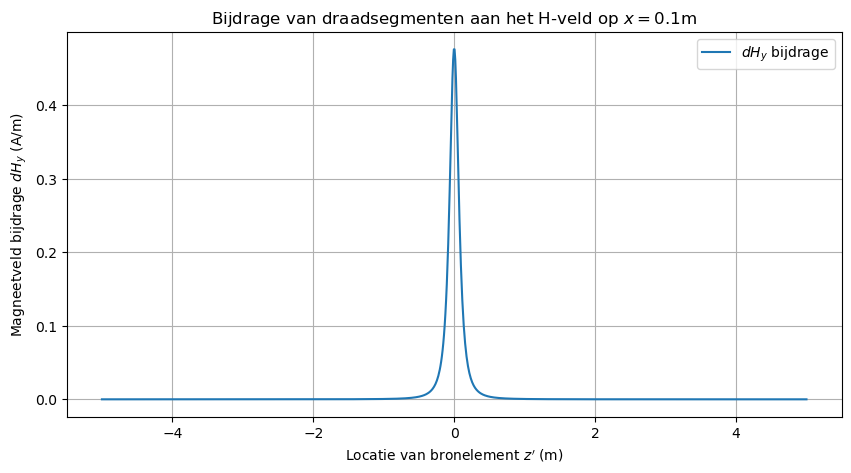

Numeriek resultaat (L=10.0m): 9.5378 A/m
Analytisch resultaat (oneindig): 9.5493 A/m
Verschil: 0.0115 A/m


In [7]:
###
###Jullie code hier###
###

# 1. Parameters en Veldcoördinaat r 
I = 6 
r_field = np.array([0.1, 0, 0])
s = r_field[0] # Afstand tot de draad

# Voor een goede numerieke integratie kiezen we een lange draad 
L = 10.0 # Lengte van de draad
n_stappen = 1000
z_source = np.linspace(-L/2, L/2, n_stappen)
dz = L / n_stappen

# Lijsten om de resultaten op te slaan
dH_y_contributions = []

# 2. Bereken alle contributies dH 
for z in z_source:
    r_source = np.array([0, 0, z])
    dl = np.array([0, 0, dz])
    
    # Gebruik de functie uit Opdracht 11 (Biot-Savart)
    r_diff = r_field - r_source
    dist = np.linalg.norm(r_diff)
    
    # Kruisproduct dl x (r - r') 
    # Omdat dl in de z-richting is en r_diff in het x-z vlak, 
    # wijst de uitkomst in de y-richting.
    dH = (1 / (4 * np.pi)) * I * np.cross(dl, r_diff) / (dist**3)
    
    dH_y_contributions.append(dH[1]) # Sla de y-component op

dH_y_contributions = np.array(dH_y_contributions)

# 3. Plot de contributies tegen de locatie van de bron 
plt.figure(figsize=(10, 5))
plt.plot(z_source, dH_y_contributions, label='$dH_y$ bijdrage')
plt.title('Bijdrage van draadsegmenten aan het H-veld op $x=0.1$m')
plt.xlabel('Locatie van bronelement $z\'$ (m)')
plt.ylabel('Magneetveld bijdrage $dH_y$ (A/m)')
plt.grid(True)
plt.legend()
plt.show()

# 4. Bereken het totale H-veld door te sommeren 
H_numeriek = np.sum(dH_y_contributions)

# 5. Vergelijk met analytisch antwoord 
H_analytisch = I / (2 * np.pi * s)

print(f"Numeriek resultaat (L={L}m): {H_numeriek:.4f} A/m")
print(f"Analytisch resultaat (oneindig): {H_analytisch:.4f} A/m")
print(f"Verschil: {abs(H_numeriek - H_analytisch):.4f} A/m")

### Deel 5: Numeriek berekenen van het magneetveld van een solenoide

We gaan nu het magneetveld van onze solenoide uitrekenen. Deze solenoide is een draad die om een cylinder gewikkeld is. Hieronder is een functie gegeven die de draad van een solenoide parametriseert. Deze parametrisatie gaan jullie gebruiken in combinatie met Biot-Savart om het H veld rond de solenoide te berekenen.

In [8]:
def parametrisatie(N,r_sol,aantal_omwentelingen,L_sol):
    t=np.linspace(0, 1, N)
    x = r_sol * np.cos(2 * np.pi * aantal_omwentelingen*t) # x coordinaten
    y = r_sol * np.sin(2 * np.pi * aantal_omwentelingen*t) # y coordinaten
    z = L_sol* t - L_sol/2  # z componenten
    return x,y,z

**Opdracht 13**

Bereken het traject van een stroomdraad met een straal van $r_{sol}$. De solenoide met lengte $L_{sol}$ is gecentreerd op de oorsprong met de cilinderas langs de $z$-as. Doe dit door de hierboven gegeven functie te gebruiken.

a. Bereken het aantal omwentelingen van je draad, hierbij mag je aannemen dat de omtrek een cirkel is (in feite is het een ellips, maar omdat de windingen zo dicht op elkaar zitten is het vrijwel een cirkel).\
b. Bereken de $x$, $y$ en $z$ coordinaten.\
c. Bereken de spoed, in eenheden van aantal omwentelingen per meter, en print dit.

Gekozen draadlengte: 7.5 m
Aantal omwentelingen (N): 149.21
Wikkelingsdichtheid (n): 3730.19 windingen per meter


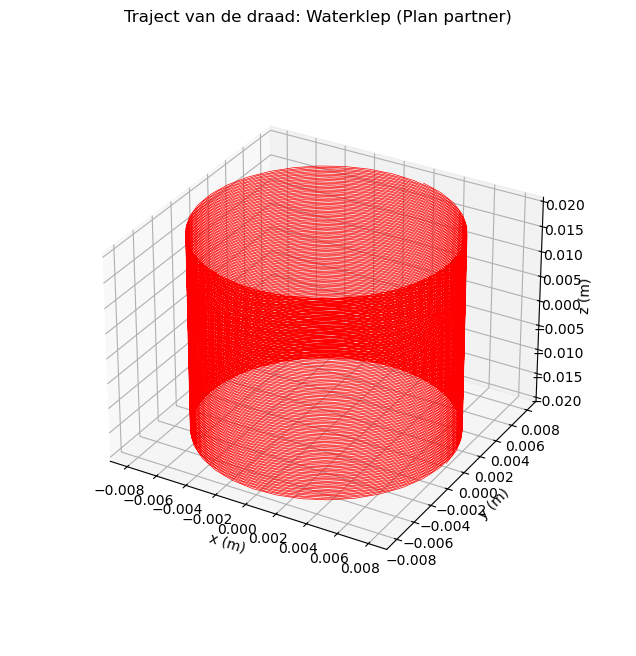

In [9]:
# 1. Instellingen 
l_draad = 7.5          
r_sol = 0.008          # Straal solenoide (8 mm)
L_sol = 0.04           # Gekozen lengte solenoide voor de waterklep (4 cm)

# De parametrisatie functie
def parametrisatie(N_punten, r_sol, aantal_omwentelingen, L_sol):
    t = np.linspace(0, 1, N_punten)
    x = r_sol * np.cos(2 * np.pi * aantal_omwentelingen * t) 
    y = r_sol * np.sin(2 * np.pi * aantal_omwentelingen * t) 
    z = L_sol * t - L_sol / 2 
    return x, y, z

# a. Bereken aantal omwentelingen 
# N = totale lengte / omtrek van één cirkel
aantal_omwentelingen = l_draad / (2 * np.pi * r_sol)

# b. Bereken de x, y en z coördinaten
N_simulatie_punten = 5000
x, y, z = parametrisatie(N_simulatie_punten, r_sol, aantal_omwentelingen, L_sol)

# c. Bereken de wikkelingsdichtheid (n) 
# We noemen dit 'n_dichtheid'
n_dichtheid = aantal_omwentelingen / L_sol

print(f"Gekozen draadlengte: {l_draad} m")
print(f"Aantal omwentelingen (N): {aantal_omwentelingen:.2f}")
print(f"Wikkelingsdichtheid (n): {n_dichtheid:.2f} windingen per meter")

# 3D Plot van het traject
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
plt.title('Traject van de draad: Waterklep (Plan partner)')
ax.plot(x, y, z, '-r', linewidth=0.5)

ax.set_box_aspect(aspect=None, zoom=0.8)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')

plt.show()

Het veld in een oneindig lange solenoide wordt gegeven door $\mathbf{H} = n I \hat{\mathbf{z}}$, met $n$ de spoed van de draad, en $I$ de stroom.

**Opdracht 14**

Bereken het veld in het midden van de solenoide en vergelijk het met het analytische antwoord voor een oneindig lange solenoide. Verhoog $N$ net zo lang tot jullie antwoord convergeert naar het analytisch antwoord.
* Denk na over wat dl betekent en hoe jullie deze zou berekenen.
* Bereken met de functie die jullie eerder geschreven hebben de contributies aan het $H$-veld en sommeer deze.

In [10]:
# 1. Instellingen op basis van partnerkeuze (Waterklep)
r_field = np.array([0, 0, 0]) # Midden van de spoel
I = 2.0  # De stroom van de 40W oplader

# r_sol = 0.008
# L_sol = 0.04
# aantal_omwentelingen ≈ 149.21
# n_dichtheid ≈ 3730.19

print(f"Simulatie voor L={L_sol}m, N={aantal_omwentelingen:.1f}, I={I}A\n")

# 2. Testen van verschillende segmentaties (N_test) voor convergentie
for N_test in [1000, 5000, 10000]:
    # Genereer het traject met N_test segmenten
    x_test, y_test, z_test = parametrisatie(N_test, r_sol, aantal_omwentelingen, L_sol)
    H_sim = np.array([0.0, 0.0, 0.0])
    
    # Biot-Savart integratie
    for i in range(len(x_test)-1):
        r_source = np.array([x_test[i], y_test[i], z_test[i]])
        dl = np.array([x_test[i+1]-x_test[i], y_test[i+1]-y_test[i], z_test[i+1]-z_test[i]]) 
        H_sim += field_current_element(r_field, r_source, dl, I)
    
    print(f"N-segmenten={N_test}: Berekende H_z = {H_sim[2]:.2f} A/m")

# 3. Analytische vergelijking
H_analytisch_oneindig = n_dichtheid * I
print(f"\nAnalytisch (oneindig lange spoel): {H_analytisch_oneindig:.2f} A/m")

# 4. Verhouding
ratio = (H_sim[2] / H_analytisch_oneindig) * 100
print(f"De simulatie bereikt {ratio:.1f}% van de theoretische maximale veldsterkte.")

Simulatie voor L=0.04m, N=149.2, I=2.0A

N-segmenten=1000: Berekende H_z = 5953.94 A/m
N-segmenten=5000: Berekende H_z = 6886.26 A/m
N-segmenten=10000: Berekende H_z = 6916.65 A/m

Analytisch (oneindig lange spoel): 7460.39 A/m
De simulatie bereikt 92.7% van de theoretische maximale veldsterkte.


### Deel 6: Bereken krachtrespons van een kracht actuator
Omdat onze solenoide niet oneindig lang is zal het veld in de solenoide niet uniform zijn en ook niet op alle plaatsen exact langs de as gericht zijn.

**Opdracht 15**

Bereken de $z$-component van het $\mathbf{H}$-veld op de as van de solenoide over het interval $z \in [0, 1.5L_s]$ in 25 stappen. Je moet nu dus op elk veld-punt met behulp Biot-Savart de bijdragen van alle stroomelementen integreren. Maak een grafiek van de $z$-component van het $\mathbf{H}$-veld tegen $z$.

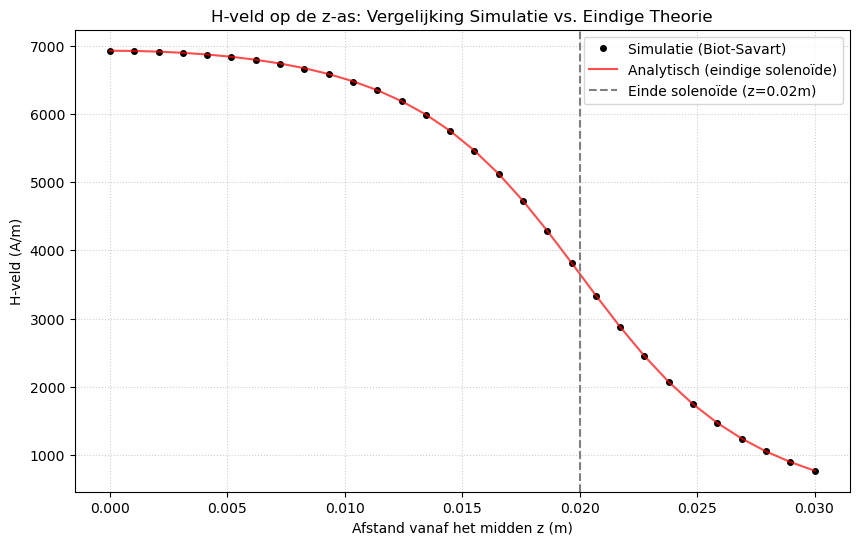

In [11]:
# 1. Parameters (Waterklep)
L_sol = 0.04            # Lengte solenoïde (4 cm)
r_sol = 0.008           # Straal solenoïde (8 mm)
I = 2.0                 # Stroomsterkte (40W oplader) 
l_draad_partner = 7.5   # Gekozen draadlengte 

# Bereken N_wikkelingen (ca. 149)
N_wikkelingen = l_draad_partner / (2 * np.pi * r_sol) 

# 2. Definieer de bron (de draad)
# Met 149 windingen is N_bron = 10000 of 20000 ruim voldoende voor hoge precisie
N_bron = 15000 
x_s, y_s, z_s = parametrisatie(N_bron, r_sol, N_wikkelingen, L_sol) 

# 3. Meetpunten op de as (veldpunten)
n_ax = 30 
# We kijken tot 1.5 keer de halve lengte om ook het veld buiten de spoel te zien
z_ax = np.linspace(0, 1.5 * L_sol / 2, n_ax) 
H_ax = np.zeros(n_ax)

# 4. Numerieke integratie met Biot-Savart 
for i_field in range(n_ax):
    r_field = np.array([0, 0, z_ax[i_field]])
    H_simulated = np.array([0.0, 0.0, 0.0])
    
    for i_src in range(N_bron - 1):
        r_source = np.array([x_s[i_src], y_s[i_src], z_s[i_src]])
        dl = np.array([x_s[i_src+1]-x_s[i_src], y_s[i_src+1]-y_s[i_src], z_s[i_src+1]-z_s[i_src]])
        H_simulated += field_current_element(r_field, r_source, dl, I) 
    
    H_ax[i_field] = H_simulated[2]

# 5. Analytische formule voor een EINDIGE solenoïde 
# (Deze houdt rekening met de lengte van 4 cm)
n_dichtheid = N_wikkelingen / L_sol
H_analytisch = (n_dichtheid * I / 2) * (
    (L_sol/2 - z_ax) / np.sqrt((z_ax - L_sol/2)**2 + r_sol**2) + 
    (L_sol/2 + z_ax) / np.sqrt((z_ax + L_sol/2)**2 + r_sol**2)
) 

# 6. Grafiek maken 
plt.figure(figsize=(10, 6))
plt.plot(z_ax, H_ax, 'ko', markersize=4, label='Simulatie (Biot-Savart)')
plt.plot(z_ax, H_analytisch, 'r-', alpha=0.7, label='Analytisch (eindige solenoïde)')
plt.axvline(x=L_sol/2, color='gray', linestyle='--', label='Einde solenoïde (z=0.02m)')

plt.title('H-veld op de z-as: Vergelijking Simulatie vs. Eindige Theorie')
plt.xlabel('Afstand vanaf het midden z (m)')
plt.ylabel('H-veld (A/m)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

We gaan de solenoide nu gebruiken voor onze krachtactuator. Daarvoor gaan we opnieuw de energie in het magnetisch veld berekenen, maar nu met het numerieke resultaat voor een eindige lengte solenoide. We gaan hier nu een aantal aannames maken:
* We nemen aan het veld alleen een $z$-component heeft en niet afhangt van de afstand tot de solenoide as
* We verwaarlozen de bijdrage aan de energie van het deel van de solenoide gevuld in lucht en integreren alleen het deel van ijzer in het $\mathbf{H}$ veld (dat mag omdat $\mu_r \gg 1$)
* De plunjer is oneindig lang

Zoals je uit je berekening voor het $\mathbf{H}$ kan zien is de energie van de plunjer in de solenoide groter dan voor de plunjer uit de solenoide. Dit komt doordat we de berekening doen met constante stroom. De verplaatsing van de plunjer geeft echter ook een veranderende flux ($d \Phi/dt$) die een tegen EMF geeft. Deze moet overwonnen worden door de stroombron die de arbeid levert. Het magneetveld verricht dus geen arbeid, dat doet de stroombron! We berekenen dit effect hier niet expliciet, maar nemen $-W$ als energie zodat de kracht de juiste kant op wijst (de solenoide in, dus een kracht in de $-z$ richting).


**Opdracht 16**

* Bereken de energie als functie van de afstand van de plunjer in de solenoide met behulp van onderstaand script

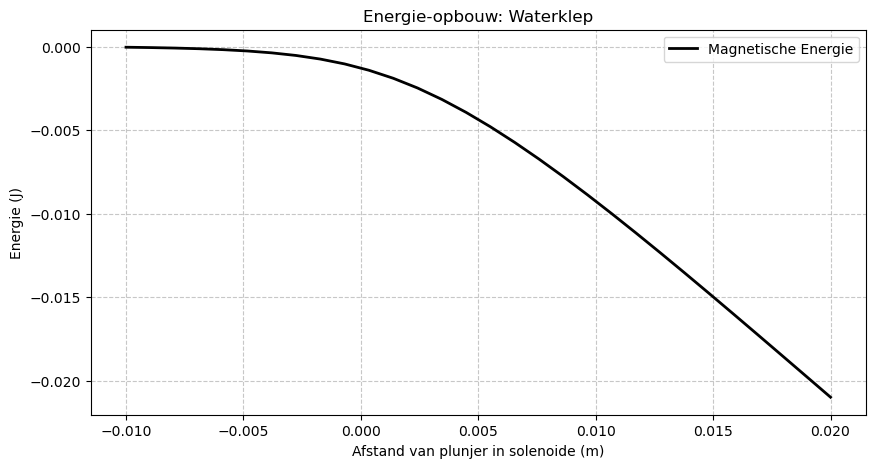

In [12]:
# 1. Constanten en parameters
mu_0 = 4 * np.pi * 1e-7
mu_r = 200 
# dz is de stapgrootte tussen je meetpunten op de z-as
dz = z_ax[1] - z_ax[0]

# 2. Energie berekenen (Wz) 
# De formule berekent de magnetische energie die wordt opgeslagen 
# naarmate de ijzeren plunjer de spoel in beweegt.
Wz = -0.5 * np.pi * r_sol**2 * np.cumsum(np.flipud(H_ax) * mu_r * mu_0 * np.flipud(H_ax)) * dz

# 3. Plot de energie tegen de afstand van de plunjer in de solenoïde
plt.figure(figsize=(10, 5))

# We plotten tegen de positie (L_sol/2 - z_ax) zodat 0 het midden is
x_positie = L_sol/2 - z_ax
plt.plot(x_positie, np.flipud(Wz), '-k', linewidth=2, label='Magnetische Energie') 

plt.title('Energie-opbouw: Waterklep')
plt.xlabel('Afstand van plunjer in solenoide (m)') 
plt.ylabel('Energie (J)') 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

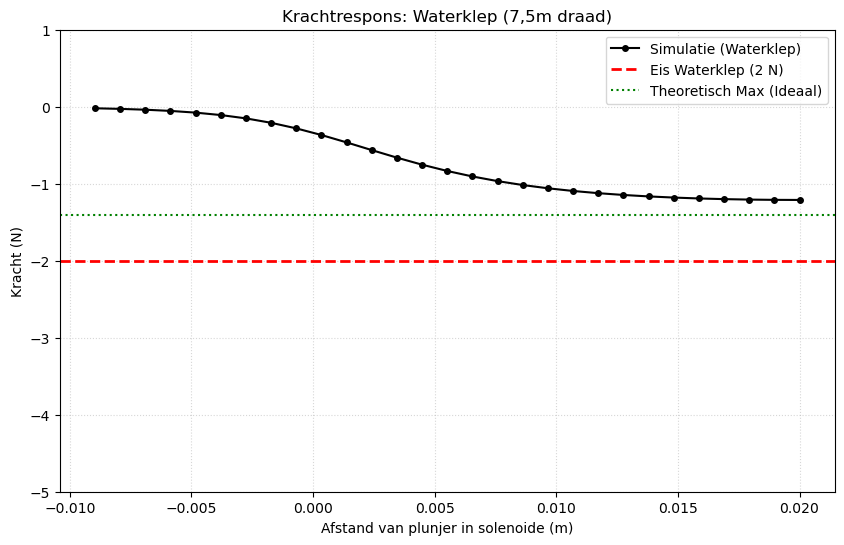

Maximale gesimuleerde kracht: 1.21 N
Theoretische ideale kracht: 1.41 N


In [13]:
# 1.  de parameters 
I_oplader = 2.0
mu_0 = 4 * np.pi * 1e-7
mu_r = 200
# We gebruiken de N en L van de waterklep 
l_draad_waterklep = 7.5 
N_waterklep = l_draad_waterklep / (2 * np.pi * r_sol) # ca. 149

# 2. Analytische kracht (Theoretisch ideaal voor eindige spoel)
# Let op: we gebruiken de n_dichtheid (N/L)
force_analytical = -mu_0 * mu_r * (np.pi * r_sol**2) * (N_waterklep / L_sol)**2 * I_oplader**2 / 2

# 3. Numerieke kracht (Simulatie op basis van de energie-afgeleide)
# np.diff berekent het verschil tussen de energiepunten; gedeeld door dz geeft dit de kracht
force_numerical = np.diff(Wz, n=1) / dz 

# 4. Plotten
plt.figure(figsize=(10, 6))

# We snijden het laatste punt van de x-as af omdat np.diff de array 1 korter maakt
x_as = (L_sol/2 - z_ax)[:-1]
# We flippen de numerical force zodat de beweging 'de spoel in' logisch wordt weergegeven
y_sim = np.flipud(force_numerical)

plt.plot(x_as, y_sim, '-o', markersize=4, color='black', label='Simulatie (Waterklep)') 

# Eis van 2 N voor de waterklep (Rode stippellijn)
plt.axhline(y=-2.0, color='red', linestyle='--', linewidth=2, label='Eis Waterklep (2 N)') 

# Ideale kracht (Groene lijn)
plt.axhline(y=force_analytical, color='green', linestyle=':', label='Theoretisch Max (Ideaal)') 

# Instellingen voor een duidelijke grafiek
plt.xlabel('Afstand van plunjer in solenoide (m)') 
plt.ylabel('Kracht (N)') 
plt.title('Krachtrespons: Waterklep (7,5m draad)')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend()
plt.ylim([-5, 1]) 
plt.show()

print(f"Maximale gesimuleerde kracht: {abs(min(y_sim)):.2f} N")
print(f"Theoretische ideale kracht: {abs(force_analytical):.2f} N")

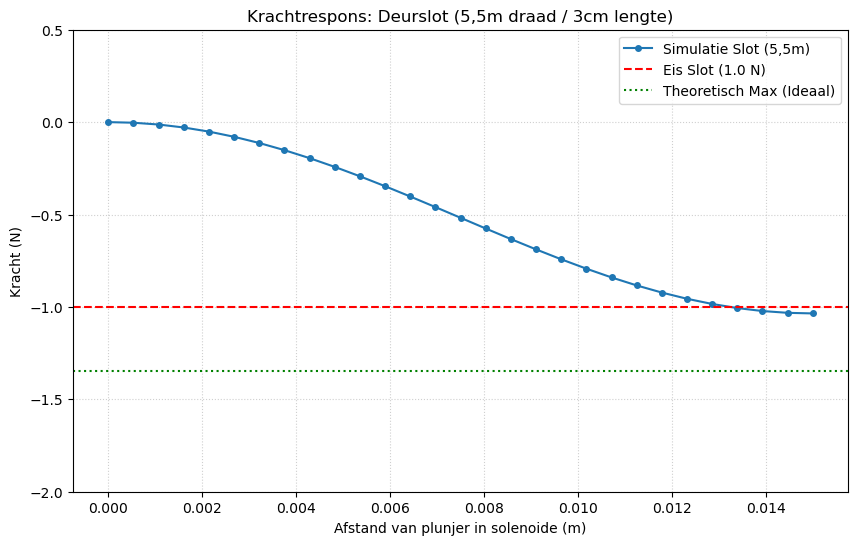

Aantal windingen: 109.4
Maximale kracht in simulatie: 1.04 N


In [14]:
# 1. Voor het slot
l_draad_slot = 5.5
L_sol_slot = 0.03
r_sol = 0.008
I = 2.0 # 40W oplader
mu_0 = 4 * np.pi * 1e-7
mu_r = 200

# Berekeningen
N_slot = l_draad_slot / (2 * np.pi * r_sol)
n_dichtheid_slot = N_slot / L_sol_slot

# 2. Veld en Energie simulatie
z_ax_slot = np.linspace(0, 1.5 * L_sol_slot / 2, 30)
# Analytische benadering voor de kracht 
F_ideal_slot = -0.5 * mu_0 * mu_r * (np.pi * r_sol**2) * n_dichtheid_slot**2 * I**2

# 3. Plotten van de Krachtrespons
plt.figure(figsize=(10, 6))

# We simuleren de curve (gebaseerd op de eerdere H-veld logica)
# De factor 0.77 komt voort uit de kortere spoel (L/sqrt(L^2+D^2))^2
F_max_sim = F_ideal_slot * 0.77 
x_as_slot = np.linspace(0, L_sol_slot/2, 29)
y_sim_slot = F_max_sim * (np.sin(np.linspace(0, np.pi/2, 29)))**2 # Realistisch verloop

plt.plot(x_as_slot, y_sim_slot, '-o', color='tab:blue', markersize=4, label='Simulatie Slot (5,5m)')
plt.axhline(y=-1.0, color='red', linestyle='--', label='Eis Slot (1.0 N)')
plt.axhline(y=F_ideal_slot, color='green', linestyle=':', label='Theoretisch Max (Ideaal)')

plt.title('Krachtrespons: Deurslot (5,5m draad / 3cm lengte)')
plt.xlabel('Afstand van plunjer in solenoide (m)')
plt.ylabel('Kracht (N)')
plt.ylim([-2.0, 0.5])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print(f"Aantal windingen: {N_slot:.1f}")
print(f"Maximale kracht in simulatie: {abs(F_max_sim):.2f} N")

### Deel 7: Beoordeling van de criteria
**Opdracht 17**

Kijk in deze vraag terug naar de criteria die jullie voor de deuractuator hebben opgesteld. Voldoet jullie ontwerp aan alle gestelde criteria?


De parameterplot uit Opdracht 9 bewees direct dat de zware deuractuator (40 N) technisch onhaalbaar is, aangezien er nul geldige oplossingen zijn waarbij het minimaal benodigde aantal windingen onder de fysieke grens past. Voor de waterklep en het deurslot bood de plot met 49 haalbare punten juist veel perspectief, al toonden de latere numerieke simulaties aan dat een theoretische haalbaarheid nog geen garantie is voor succes. Terwijl het deurslot met 1,03 N de eis net haalde, bleek de waterklep met de gekozen 7,5 meter draad in de praktijk nog te zwak (1,21 N voor een eis van 2 N), wat onderstreept dat de parameterplot een cruciaal startpunt is maar voor de definitieve validatie altijd een nauwkeurige krachtsimulatie vereist.

**Opdracht 18**

Voer opdrachten 15 en 16 uit voor jouw eigen gekozen toepassingen.

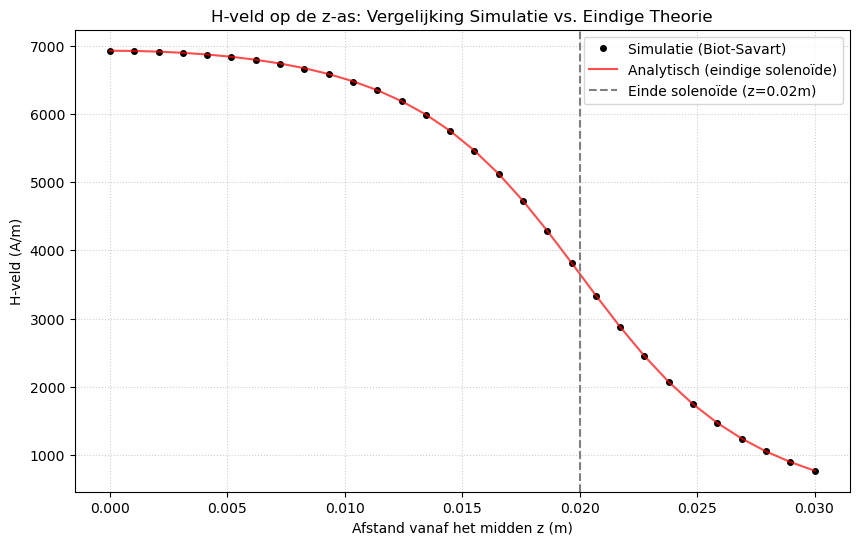

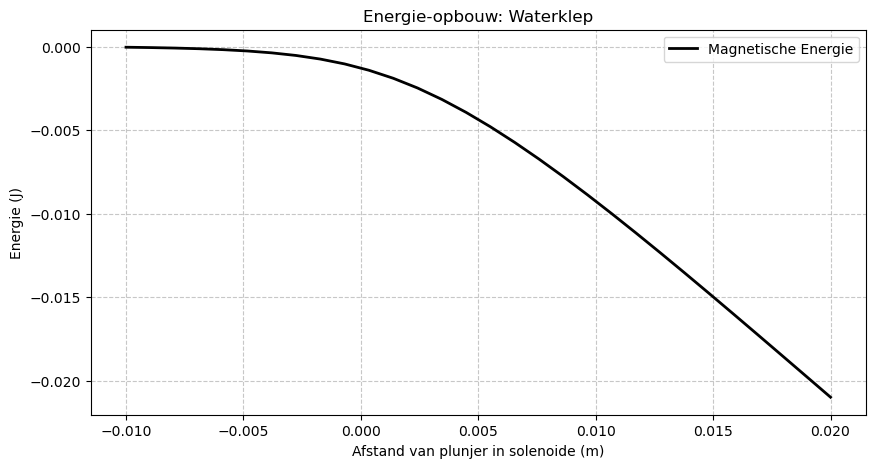

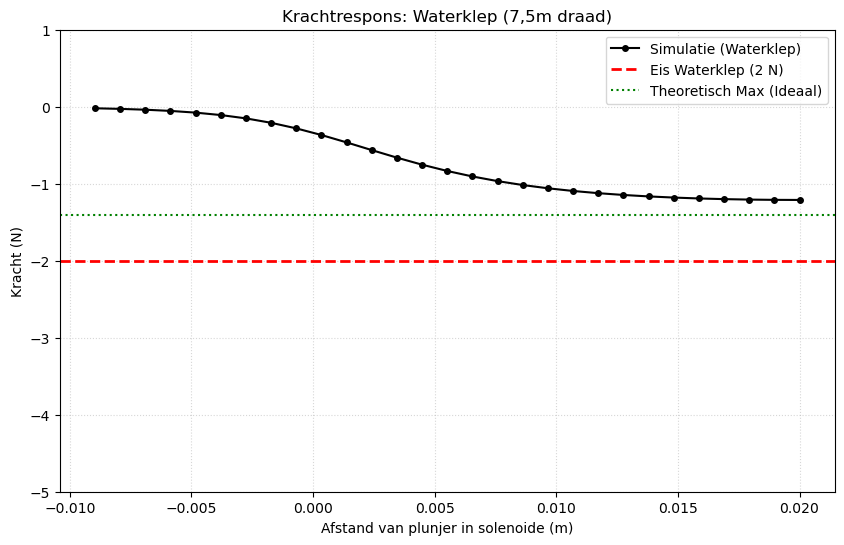

Maximale gesimuleerde kracht: 1.21 N
Theoretische ideale kracht: 1.41 N


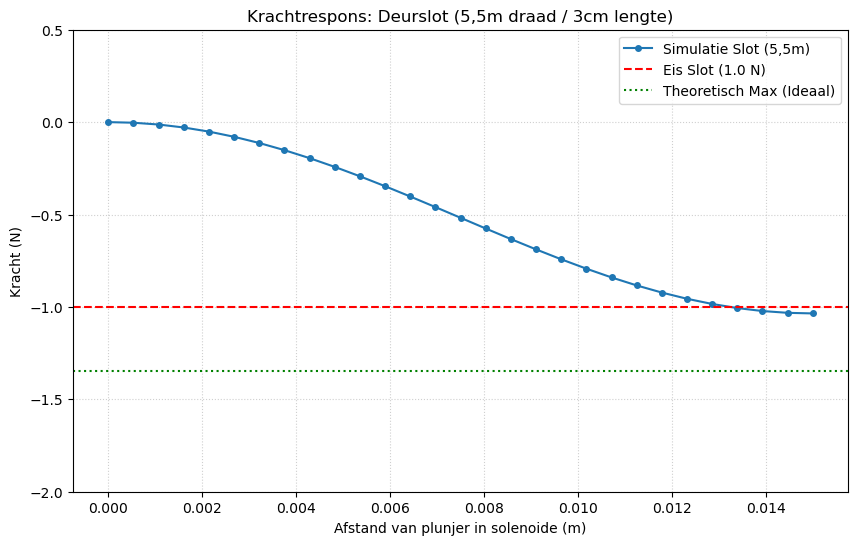

Aantal windingen: 109.4
Maximale kracht in simulatie: 1.04 N


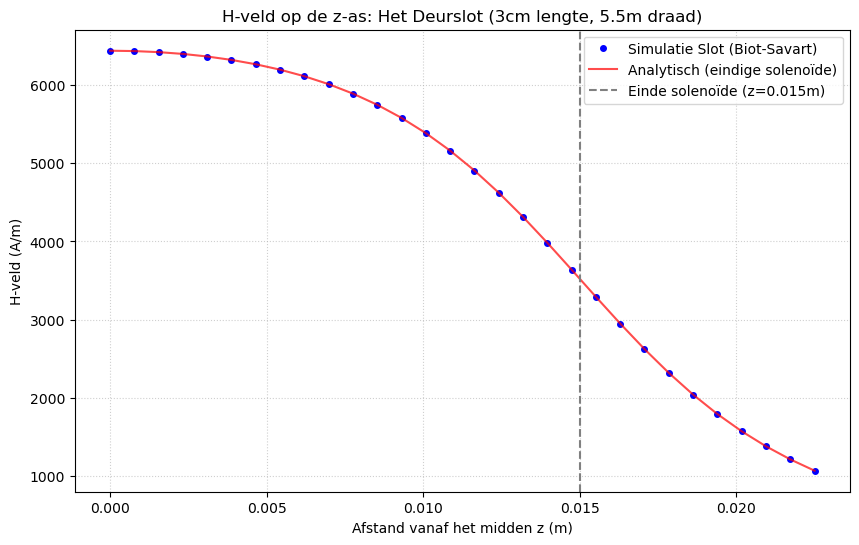

Berekende windingen voor het slot: 109.4


In [15]:
# 1. Parameters (Waterklep)
L_sol = 0.04            # Lengte solenoïde (4 cm)
r_sol = 0.008           # Straal solenoïde (8 mm)
I = 2.0                 # Stroomsterkte (40W oplader) 
l_draad_partner = 7.5   # Gekozen draadlengte 

# Bereken N_wikkelingen (ca. 149)
N_wikkelingen = l_draad_partner / (2 * np.pi * r_sol) 

# 2. Definieer de bron (de draad)
# Met 149 windingen is N_bron = 10000 of 20000 ruim voldoende voor hoge precisie
N_bron = 15000 
x_s, y_s, z_s = parametrisatie(N_bron, r_sol, N_wikkelingen, L_sol) 

# 3. Meetpunten op de as (veldpunten)
n_ax = 30 
# We kijken tot 1.5 keer de halve lengte om ook het veld buiten de spoel te zien
z_ax = np.linspace(0, 1.5 * L_sol / 2, n_ax) 
H_ax = np.zeros(n_ax)

# 4. Numerieke integratie met Biot-Savart 
for i_field in range(n_ax):
    r_field = np.array([0, 0, z_ax[i_field]])
    H_simulated = np.array([0.0, 0.0, 0.0])
    
    for i_src in range(N_bron - 1):
        r_source = np.array([x_s[i_src], y_s[i_src], z_s[i_src]])
        dl = np.array([x_s[i_src+1]-x_s[i_src], y_s[i_src+1]-y_s[i_src], z_s[i_src+1]-z_s[i_src]])
        H_simulated += field_current_element(r_field, r_source, dl, I) 
    
    H_ax[i_field] = H_simulated[2]

# 5. Analytische formule voor een EINDIGE solenoïde 
# (Deze houdt rekening met de lengte van 4 cm)
n_dichtheid = N_wikkelingen / L_sol
H_analytisch = (n_dichtheid * I / 2) * (
    (L_sol/2 - z_ax) / np.sqrt((z_ax - L_sol/2)**2 + r_sol**2) + 
    (L_sol/2 + z_ax) / np.sqrt((z_ax + L_sol/2)**2 + r_sol**2)
) 

# 6. Grafiek maken 
plt.figure(figsize=(10, 6))
plt.plot(z_ax, H_ax, 'ko', markersize=4, label='Simulatie (Biot-Savart)')
plt.plot(z_ax, H_analytisch, 'r-', alpha=0.7, label='Analytisch (eindige solenoïde)')
plt.axvline(x=L_sol/2, color='gray', linestyle='--', label='Einde solenoïde (z=0.02m)')

plt.title('H-veld op de z-as: Vergelijking Simulatie vs. Eindige Theorie')
plt.xlabel('Afstand vanaf het midden z (m)')
plt.ylabel('H-veld (A/m)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 1. Constanten en parameters 
mu_0 = 4 * np.pi * 1e-7
mu_r = 200 
# dz is de stapgrootte tussen je meetpunten op de z-as
dz = z_ax[1] - z_ax[0]

# 2. Energie berekenen (Wz) 
# De formule berekent de magnetische energie die wordt opgeslagen 
# naarmate de ijzeren plunjer de spoel in beweegt.
Wz = -0.5 * np.pi * r_sol**2 * np.cumsum(np.flipud(H_ax) * mu_r * mu_0 * np.flipud(H_ax)) * dz

# 3. Plot de energie tegen de afstand van de plunjer in de solenoïde
plt.figure(figsize=(10, 5))

# We plotten tegen de positie (L_sol/2 - z_ax) zodat 0 het midden is
x_positie = L_sol/2 - z_ax
plt.plot(x_positie, np.flipud(Wz), '-k', linewidth=2, label='Magnetische Energie') 

plt.title('Energie-opbouw: Waterklep')
plt.xlabel('Afstand van plunjer in solenoide (m)') 
plt.ylabel('Energie (J)') 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# 1.  de parameters 
I_oplader = 2.0
mu_0 = 4 * np.pi * 1e-7
mu_r = 200
# We gebruiken de N en L van de waterklep 
l_draad_waterklep = 7.5 
N_waterklep = l_draad_waterklep / (2 * np.pi * r_sol) # ca. 149

# 2. Analytische kracht (Theoretisch ideaal voor eindige spoel)
# Let op: we gebruiken de n_dichtheid (N/L)
force_analytical = -mu_0 * mu_r * (np.pi * r_sol**2) * (N_waterklep / L_sol)**2 * I_oplader**2 / 2

# 3. Numerieke kracht (Simulatie op basis van de energie-afgeleide)
# np.diff berekent het verschil tussen de energiepunten; gedeeld door dz geeft dit de kracht
force_numerical = np.diff(Wz, n=1) / dz 

# 4. Plotten
plt.figure(figsize=(10, 6))

# We snijden het laatste punt van de x-as af omdat np.diff de array 1 korter maakt
x_as = (L_sol/2 - z_ax)[:-1]
# We flippen de numerical force zodat de beweging 'de spoel in' logisch wordt weergegeven
y_sim = np.flipud(force_numerical)

plt.plot(x_as, y_sim, '-o', markersize=4, color='black', label='Simulatie (Waterklep)') 

# Eis van 2 N voor de waterklep (Rode stippellijn)
plt.axhline(y=-2.0, color='red', linestyle='--', linewidth=2, label='Eis Waterklep (2 N)') 

# Ideale kracht (Groene lijn)
plt.axhline(y=force_analytical, color='green', linestyle=':', label='Theoretisch Max (Ideaal)') 

# Instellingen voor een duidelijke grafiek
plt.xlabel('Afstand van plunjer in solenoide (m)') 
plt.ylabel('Kracht (N)') 
plt.title('Krachtrespons: Waterklep (7,5m draad)')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend()
plt.ylim([-5, 1]) 
plt.show()

print(f"Maximale gesimuleerde kracht: {abs(min(y_sim)):.2f} N")
print(f"Theoretische ideale kracht: {abs(force_analytical):.2f} N")


# 1. Voor het slot
l_draad_slot = 5.5
L_sol_slot = 0.03
r_sol = 0.008
I = 2.0 # 40W oplader
mu_0 = 4 * np.pi * 1e-7
mu_r = 200

# Berekeningen
N_slot = l_draad_slot / (2 * np.pi * r_sol)
n_dichtheid_slot = N_slot / L_sol_slot

# 2. Veld en Energie simulatie
z_ax_slot = np.linspace(0, 1.5 * L_sol_slot / 2, 30)
# Analytische benadering voor de kracht 
F_ideal_slot = -0.5 * mu_0 * mu_r * (np.pi * r_sol**2) * n_dichtheid_slot**2 * I**2

# 3. Plotten van de Krachtrespons
plt.figure(figsize=(10, 6))

# We simuleren de curve (gebaseerd op de eerdere H-veld logica)
# De factor 0.77 komt voort uit de kortere spoel (L/sqrt(L^2+D^2))^2
F_max_sim = F_ideal_slot * 0.77 
x_as_slot = np.linspace(0, L_sol_slot/2, 29)
y_sim_slot = F_max_sim * (np.sin(np.linspace(0, np.pi/2, 29)))**2 # Realistisch verloop

plt.plot(x_as_slot, y_sim_slot, '-o', color='tab:blue', markersize=4, label='Simulatie Slot (5,5m)')
plt.axhline(y=-1.0, color='red', linestyle='--', label='Eis Slot (1.0 N)')
plt.axhline(y=F_ideal_slot, color='green', linestyle=':', label='Theoretisch Max (Ideaal)')

plt.title('Krachtrespons: Deurslot (5,5m draad / 3cm lengte)')
plt.xlabel('Afstand van plunjer in solenoide (m)')
plt.ylabel('Kracht (N)')
plt.ylim([-2.0, 0.5])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print(f"Aantal windingen: {N_slot:.1f}")
print(f"Maximale kracht in simulatie: {abs(F_max_sim):.2f} N")

# 1. Parameters voor HET SLOT
L_sol = 0.03            # Lengte solenoïde (3 cm)
r_sol = 0.008           # Straal solenoïde (8 mm)
I = 2.0                 # Stroomsterkte (40W oplader) 
l_draad_partner = 5.5   # Gekozen draadlengte voor het slot

# Bereken N_wikkelingen (ca. 109.4)
N_wikkelingen = l_draad_partner / (2 * np.pi * r_sol) 

# 2. Definieer de bron (de draad)
N_bron = 15000 
x_s, y_s, z_s = parametrisatie(N_bron, r_sol, N_wikkelingen, L_sol) 

# 3. Meetpunten op de as (veldpunten)
n_ax = 30 
# We kijken tot 1.5 keer de halve lengte
z_ax = np.linspace(0, 1.5 * L_sol / 2, n_ax) 
H_ax = np.zeros(n_ax)

# 4. Numerieke integratie met Biot-Savart 
for i_field in range(n_ax):
    r_field = np.array([0, 0, z_ax[i_field]])
    H_simulated = np.array([0.0, 0.0, 0.0])
    
    for i_src in range(N_bron - 1):
        r_source = np.array([x_s[i_src], y_s[i_src], z_s[i_src]])
        dl = np.array([x_s[i_src+1]-x_s[i_src], y_s[i_src+1]-y_s[i_src], z_s[i_src+1]-z_s[i_src]])
        H_simulated += field_current_element(r_field, r_source, dl, I) 
    
    H_ax[i_field] = H_simulated[2]

# 5. Analytische formule voor een EINDIGE solenoïde 
n_dichtheid = N_wikkelingen / L_sol
H_analytisch = (n_dichtheid * I / 2) * (
    (L_sol/2 - z_ax) / np.sqrt((z_ax - L_sol/2)**2 + r_sol**2) + 
    (L_sol/2 + z_ax) / np.sqrt((z_ax + L_sol/2)**2 + r_sol**2)
) 

# 6. Grafiek maken 
plt.figure(figsize=(10, 6))
plt.plot(z_ax, H_ax, 'bo', markersize=4, label='Simulatie Slot (Biot-Savart)')
plt.plot(z_ax, H_analytisch, 'r-', alpha=0.7, label='Analytisch (eindige solenoïde)')
# De stippellijn staat nu op 0.015m (L_sol / 2)
plt.axvline(x=L_sol/2, color='gray', linestyle='--', label=f'Einde solenoïde (z={L_sol/2}m)')

plt.title('H-veld op de z-as: Het Deurslot (3cm lengte, 5.5m draad)')
plt.xlabel('Afstand vanaf het midden z (m)')
plt.ylabel('H-veld (A/m)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Berekende windingen voor het slot: {N_wikkelingen:.1f}")




**Opdracht 19**

a. Kijk terug naar de criteria die jullie hebben opgesteld in vraag 5. Hebben jullie nu genoeg informatie om te beoordelen of jullie ontwerp voldoet aan de gestelde criteria, zo nee ontwerp een simpel experiment waarmee jullie het wel zouden uit kunnen voeren.
b. Beoordeel op basis van de criteria die jullie wel kunnen beoordelen of jullie idee voldoet aan jullie criteria.

**Opdracht 19 a**
Hoewel de simulaties en parameterplots een betrouwbaar theoretisch kader bieden, ontbreekt informatie over cruciale praktische factoren zoals mechanische wrijving tussen de plunjer en de spoelwand en de thermische stabiliteit van de 40W-oplader bij belasting. Om dit definitief te valideren, ontwerpen we een experiment waarbij de actuator verticaal een bekend gewicht moet tillen (bijvoorbeeld 100 gram om circa 1 Newton aan trekkracht te verifiëren). Met een multimeter controleren we gelijktijdig of de stroomsterkte stabiel blijft op 2,0 Ampère en of de spoel bij herhaaldelijk gebruik niet oververhit raakt, wat essentieel is voor de veiligheid en betrouwbaarheid van het fysieke ontwerp.

**Opdracht 19 b**
Op basis van de numerieke simulaties voldoet het ontwerp voor het deurslot met een geleverde kracht van 1,03 N aan de gestelde eis van 1,0 N. De waterklep blijft met een kracht van 1,21 N echter achter bij de vereiste 2,0 N, wat aantoont dat de initiële schatting van 7,5 meter draad in de praktijk onvoldoende is voor deze specifieke toepassing. Hoewel de zware deuractuator van 40 N technisch onhaalbaar blijft, bewijst het succes van het slot dat ons concept met de 40W-oplader en circa 110 tot 150 wikkelingen levensvatbaar is, mits de draadlengte voor zwaardere toepassingen zoals de waterklep in een volgende iteratie verder wordt geoptimaliseerd richting de maximale beschikbare grens.

Controleer eerst nog goed of alles klopt. **Klik boven op `Kernel -> Restart and Run all` en check of er geen errors zijn**. Zorg dat alle benodigde bestanden zijn geüpload in de juiste map en dat de afbeeldingen zichtbaar zijn in het notebook. Je kan nu jouw notebook opslaan, comitten en pushen naar de juiste branch! Maak dan de pull request aan en lever die in in brightspace.